In [306]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

qualidade_ar = pd.read_csv('Brasilia_Air_Quality.csv')
qualidade_ar.head()

,Unnamed: 0,Date,City,CO,NO2,SO2,O3,PM2.5,PM10,AQI
0,0,2025-01-01 00:00:00+00:00,Brasilia,325.0,21.1,2.5,35.0,15.4,15.6,20.483337
1,1,2025-01-01 01:00:00+00:00,Brasilia,369.0,20.8,2.7,35.0,15.1,15.3,20.425000
2,2,2025-01-01 02:00:00+00:00,Brasilia,419.0,20.4,3.0,34.0,15.6,15.8,20.333332
3,3,2025-01-01 03:00:00+00:00,Brasilia,451.0,20.5,3.1,33.0,16.4,16.6,20.258335
4,4,2025-01-01 04:00:00+00:00,Brasilia,458.0,22.1,3.0,29.0,17.7,17.8,20.316668


In [307]:
# Tratamento dos dados

qualidade_ar.dtypes

Unnamed: 0      int64
Date           object
City           object
CO            float64
NO2           float64
SO2           float64
O3            float64
PM2.5         float64
PM10          float64
AQI           float64
dtype: object

In [308]:
qualidade_ar.rename(columns={'Date':'Data_Hora', 'City' : 'Cidade', 'CO': 'Conc_Monoxido_Carbono', 'NO2' : 'Conc_Nitrogenio',
'SO2' : 'Conc_Sulfúrico', 'O3' : 'Conc_Ozone', 'AQI' : 'Indice_Qualidade_Ar'}, inplace=True)

In [309]:
qualidade_ar['Data_Hora'] = pd.to_datetime(qualidade_ar['Data_Hora'])
qualidade_ar['Data_Hora'].dt.normalize()

0      2025-01-01 00:00:00+00:00
1      2025-01-01 00:00:00+00:00
2      2025-01-01 00:00:00+00:00
3      2025-01-01 00:00:00+00:00
4      2025-01-01 00:00:00+00:00
                  ...           
8755   2025-12-31 00:00:00+00:00
8756   2025-12-31 00:00:00+00:00
8757   2025-12-31 00:00:00+00:00
8758   2025-12-31 00:00:00+00:00
8759   2025-12-31 00:00:00+00:00
Name: Data_Hora, Length: 8760, dtype: datetime64[ns, UTC]

In [310]:
qualidade_ar['Hora'] = qualidade_ar['Data_Hora'].dt.hour

In [311]:
qualidade_ar.isnull().sum()

Unnamed: 0               0
Data_Hora                0
Cidade                   0
Conc_Monoxido_Carbono    0
Conc_Nitrogenio          0
Conc_Sulfúrico           0
Conc_Ozone               0
PM2.5                    0
PM10                     0
Indice_Qualidade_Ar      0
Hora                     0
dtype: int64

In [316]:
# Sumário das colunas númericas
qualidade_ar.describe()

,Unnamed: 0,Conc_Monoxido_Carbono,Conc_Nitrogenio,Conc_Sulfúrico,Conc_Ozone,PM2.5,PM10,Indice_Qualidade_Ar,Hora
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,4379.500000,226.474658,9.506918,1.685936,67.904566,6.301655,6.577808,28.700643,11.500000
std,2528.938512,111.771706,9.702633,0.879948,28.416922,4.550559,4.592079,11.087385,6.922582
min,0.000000,87.000000,0.000000,0.300000,0.000000,0.000000,0.000000,7.600000,0.000000
25%,2189.750000,156.000000,2.600000,1.000000,46.000000,3.100000,3.400000,20.135417,5.750000
50%,4379.500000,201.000000,6.400000,1.500000,67.000000,5.000000,5.400000,27.200000,11.500000
75%,6569.250000,258.000000,12.700000,2.200000,88.000000,8.000000,8.300000,35.200000,17.250000
max,8759.000000,1203.000000,68.900000,6.000000,162.000000,34.200000,34.300000,65.818184,23.000000


In [313]:
# Mensurando variabilidade dos dados ( O quão espalhado são os dados)

col_mudar = []

for col in qualidade_ar.columns:
    if pd.api.types.is_float_dtype(qualidade_ar[col]):
        col_mudar.append(col)

for col in col_mudar:
    print(f"\nAtributo: {col}")
    print("Desvio Padrão:", qualidade_ar[col].std())
    print("Variância:", qualidade_ar[col].var())
    print("Range:", qualidade_ar[col].max() - qualidade_ar[col].min())


Atributo: Conc_Monoxido_Carbono
Desvio Padrão: 111.77170617967003
Variância: 12492.914302314488
Range: 1116.0

Atributo: Conc_Nitrogenio
Desvio Padrão: 9.702632521009262
Variância: 94.14107783774654
Range: 68.9

Atributo: Conc_Sulfúrico
Desvio Padrão: 0.8799479561591599
Variância: 0.7743084055486829
Range: 5.7

Atributo: Conc_Ozone
Desvio Padrão: 28.41692156740273
Variância: 807.5214313679186
Range: 162.0

Atributo: PM2.5
Desvio Padrão: 4.550558618708919
Variância: 20.707583742306024
Range: 34.2

Atributo: PM10
Desvio Padrão: 4.592079158089016
Variância: 21.087190994155524
Range: 34.3

Atributo: Indice_Qualidade_Ar
Desvio Padrão: 11.087385027306363
Variância: 122.9301067437373
Range: 58.218184


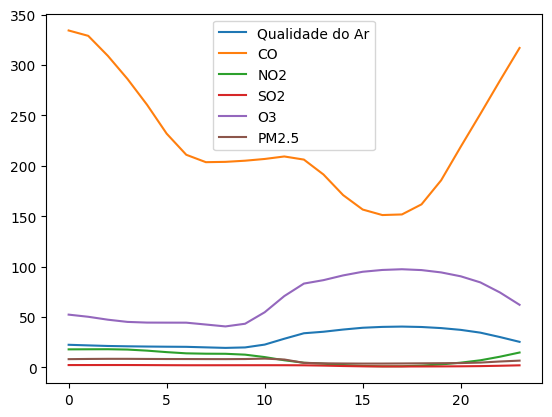

In [ ]:
# Analise de Qualidade de Ar por Hora

media_por_hora = (
    qualidade_ar
    .groupby('Hora')['Indice_Qualidade_Ar']
    .mean()
)

media_por_hora_carbono = (
        qualidade_ar
    .groupby('Hora')['Conc_Monoxido_Carbono']
    .mean()
)

media_por_hora_nitro = (
        qualidade_ar
    .groupby('Hora')['Conc_Nitrogenio']
    .mean()
)

media_por_hora_sulf = (
        qualidade_ar
    .groupby('Hora')['Conc_Sulfúrico']
    .mean()
)

media_por_hora_oz = (
        qualidade_ar
    .groupby('Hora')['Conc_Ozone']
    .mean()
)

media_por_hora_PM25 = (
        qualidade_ar
    .groupby('Hora')['PM2.5']
    .mean()
)

plt.plot(media_por_hora.index, media_por_hora.values, label = 'Qualidade do Ar')
plt.plot(media_por_hora_carbono.index, media_por_hora_carbono.values, label = 'CO')
plt.plot(media_por_hora_nitro.index, media_por_hora_nitro.values, label='NO2')
plt.plot(media_por_hora_sulf.index, media_por_hora_sulf.values, label='SO2')
plt.plot(media_por_hora_oz.index, media_por_hora_oz.values, label='O3')
plt.plot(media_por_hora_PM25.index, media_por_hora_PM25.values, label='PM2.5')
plt.legend()
plt.show()